# Visualizing distributions of data

An early step in any effort to analyze or model data should be to understand how the variables are distributed. Techniques for distribution visualization can provide quick answers to many important questions.

1. What **range** do the observations cover?
2. What is their **central tendency**?
3. Are they heavily **skewed** in one direction?
4. Is there evidence for **bimodality**?
5. Are there significant **outliers**?
6. Do the answers to these questions vary **across subsets** defined by other variables?

By convention, the alias `sns` is used for `seaborn`:

In [1]:
import seaborn as sns

Let's load smoe data and look at some plots possible with seaborn.

In [2]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


The [distributions module](https://seaborn.pydata.org/api.html#distribution-api) contains several functions designed to answer questions such as these.

1. The **axes-level** functions are [`histplot()`](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot), [`kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html#seaborn.kdeplot), [`ecdfplot()`](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html#seaborn.ecdfplot), and [`rugplot()`](https://seaborn.pydata.org/generated/seaborn.rugplot.html#seaborn.rugplot).
2. They are grouped together within the **figure-level** [`displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot), [`jointplot()`](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot), and [`pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) functions.

![](../assets/displot.png)

### Plotting univariate histograms

A **histogram** is a bar plot where the axis representing the data variable is divided into a set of discrete bins and the count of observations falling within each bin is shown using the height of the corresponding bar.

We use the `sns.displot()` function with the default value `kind="hist"`:

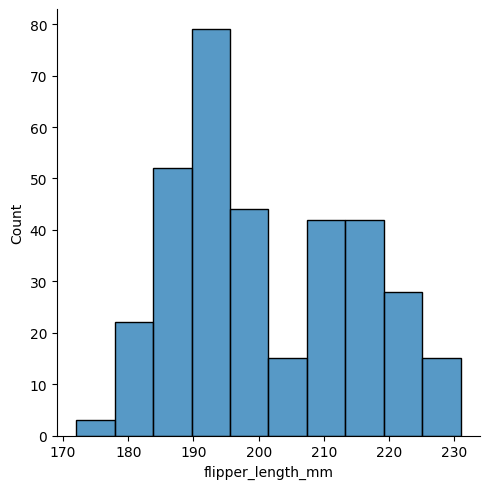

In [3]:
sns.displot(
    data=penguins,
    kind="hist",
    x="flipper_length_mm",
)

This plot immediately affords a few insights about the `flipper_length_mm` variable. For instance, we can see that the most common flipper length is about 195 mm, but the distribution appears bimodal, so this one number does not represent the data well.

**It is always advisable to check that your impressions of the distribution are consistent across different bin sizes**.

You may choose to adjust the size / number of bins in two ways:

- By Width: `binwidth=10`
- By Count: `bins=20`

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

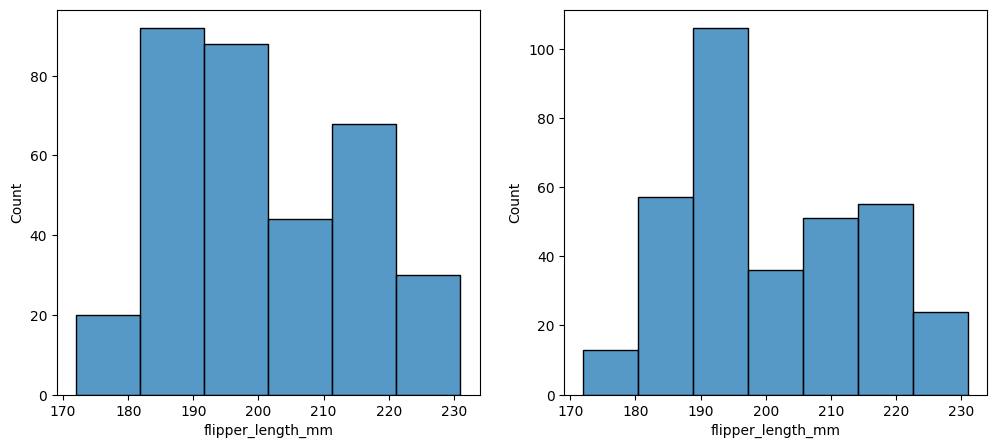

In [4]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(12, 5)
)

# Left
sns.histplot(
    penguins,
    x="flipper_length_mm",
    binwidth=10,         # by width
    ax=axes[0]
)

# Right
sns.histplot(
    penguins,
    x="flipper_length_mm",
    bins=7,               # by count
    ax=axes[1]
)

### Bar plot

It’s also possible to visualize the distribution of a categorical variable using the logic of a histogram.

In [5]:
tips = sns.load_dataset("tips")
tips['size'].value_counts().sort_index()

size
1      4
2    156
3     38
4     37
5      5
6      4
Name: count, dtype: int64

In the default case, the bin width may be too small, creating awkward gaps in the distribution. Hence either:

- specify the precise bin breaks by passing an array to bins: `bins=[1, 2, 3, 4, 5, 6, 7]`
- automatically specify them with: `discrete=True`
- discrete bins are automatically set for categorical variables, but it may also be helpful to “`shrink`” the bars slightly to emphasize the categorical nature of the axis:

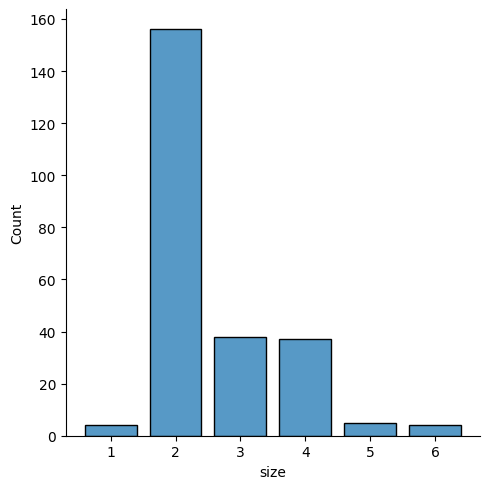

In [6]:
sns.displot(tips, kind='hist', x="size", discrete=True, shrink=0.8)

## Conditioning on other variables

Once you understand the distribution of a variable, the next step is often to ask: **whether features of that distribution differ across other variables in the dataset**. For example, what accounts for the bimodal distribution of flipper lengths that we saw above?

- Assigning a variable to `hue="species"` (or other categorical variables) will draw a separate histogram for each of its unique values and distinguish them by color.


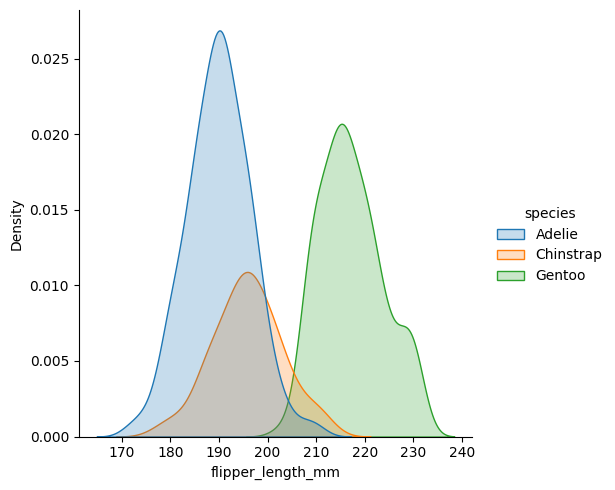

In [7]:
sns.displot(
    penguins,
    kind='kde',
    fill=True,
    x="flipper_length_mm",
    hue="species",   # Distinguish by color
)

- Overlapping distribution may be stacked via `multiple="stack"`, useful in histograms

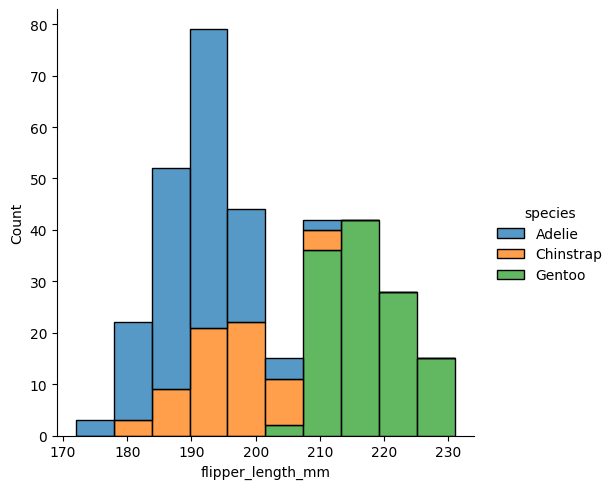

In [8]:
sns.displot(
    penguins,
    x="flipper_length_mm",
    hue="species",   # Distinguish by color
    multiple="stack" # On top of each other
)

It is also possible to draw each individual distribution in a separate subplot: by assigning the second variable to `col` or `row` rather than (or in addition to) `hue`:

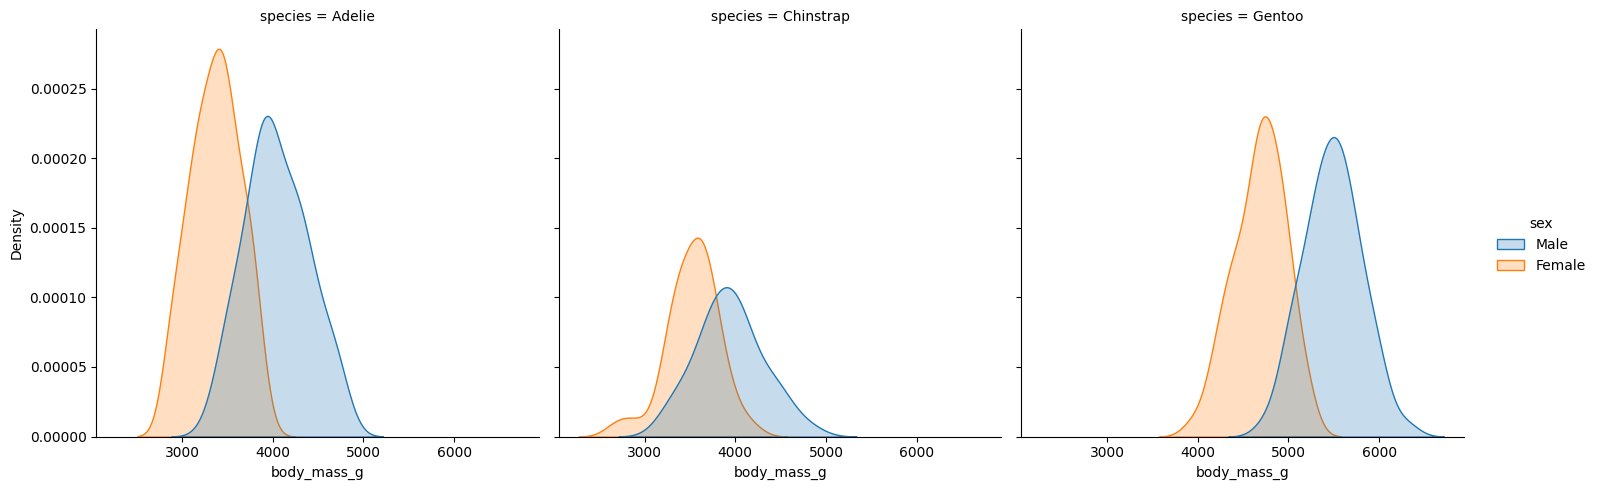

In [16]:
sns.displot(
    penguins,
    kind='kde',
    fill=True,
    x="body_mass_g",
    hue="sex",
    col="species",
)

Some distributions won't show up simply because some species are exclusive to some islands.

::: {.callout-note}

Try replacing `col` with `row` or `hue`.

:::

None of these approaches are perfect, and we will soon see some alternatives to a histogram that are better-suited to the task of comparison.

## Normalized histogram statistics

- **When the subsets have unequal numbers of observations**, comparing their distributions in terms of counts may not be ideal.
- One solution is to normalize the counts using the `stat` parameter:
- By default, however, **the normalization is applied to the entire distribution**, so this simply rescales the height of the bars.
- By setting `common_norm=False`, **each subset will be normalized independently**

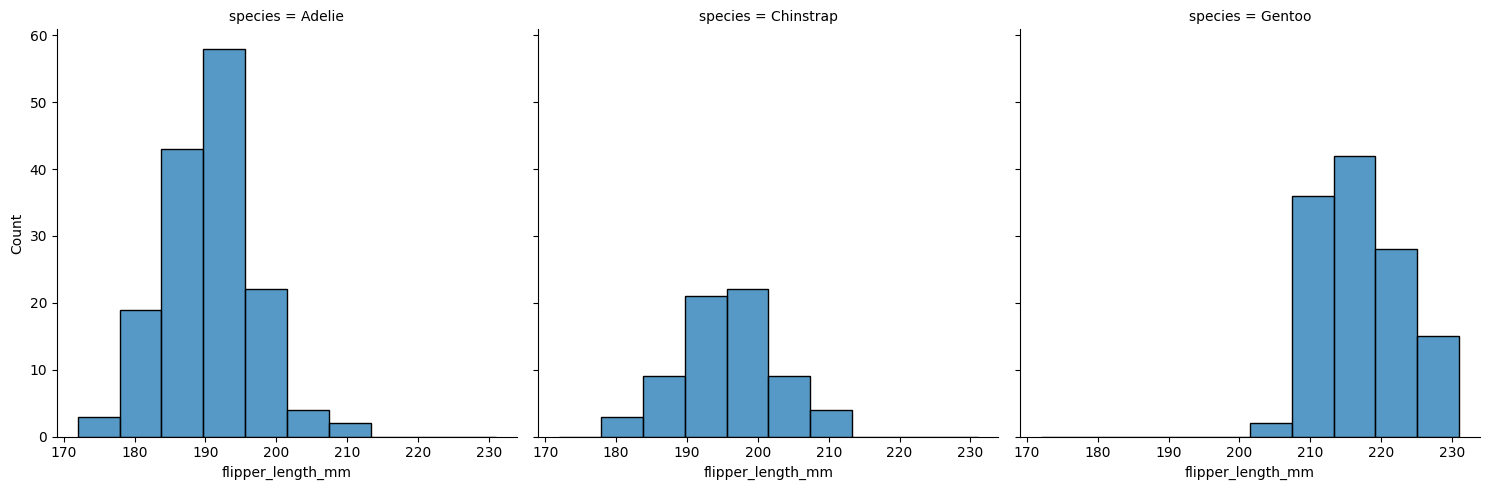

In [11]:
sns.displot(
    penguins, x="flipper_length_mm", col="species",
    # stat="density",   # stat="density"; Adjust for unequal counts
    # common_norm=False, # common_norm=False; to normalize each subset independently
)

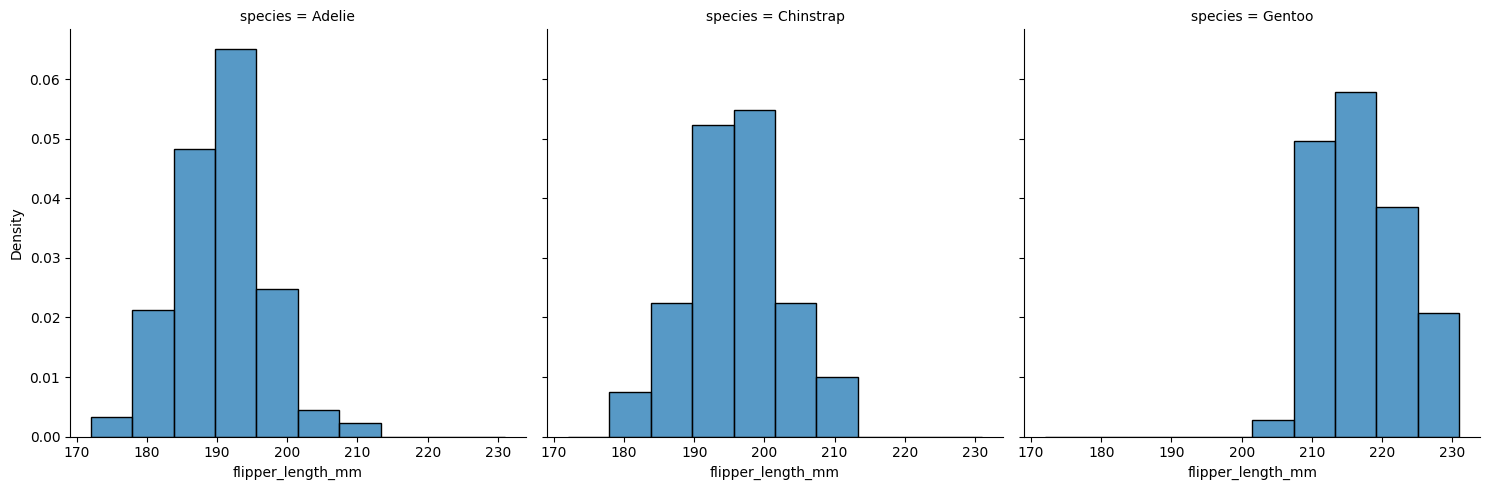

In [12]:
sns.displot(
    penguins, x="flipper_length_mm", col="species",
    stat="density",    # stat="density"; Adjust for unequal counts
    common_norm=False, # common_norm=False; to normalize each subset independently
)

- Density normalization scales the bars so that **their areas sum to 1**. As a result, the density axis is not directly interpretable.
- Another option is to normalize the bars so that **their heights sum to 1**. This makes most sense when the variable is discrete, but it is an option for all histograms:

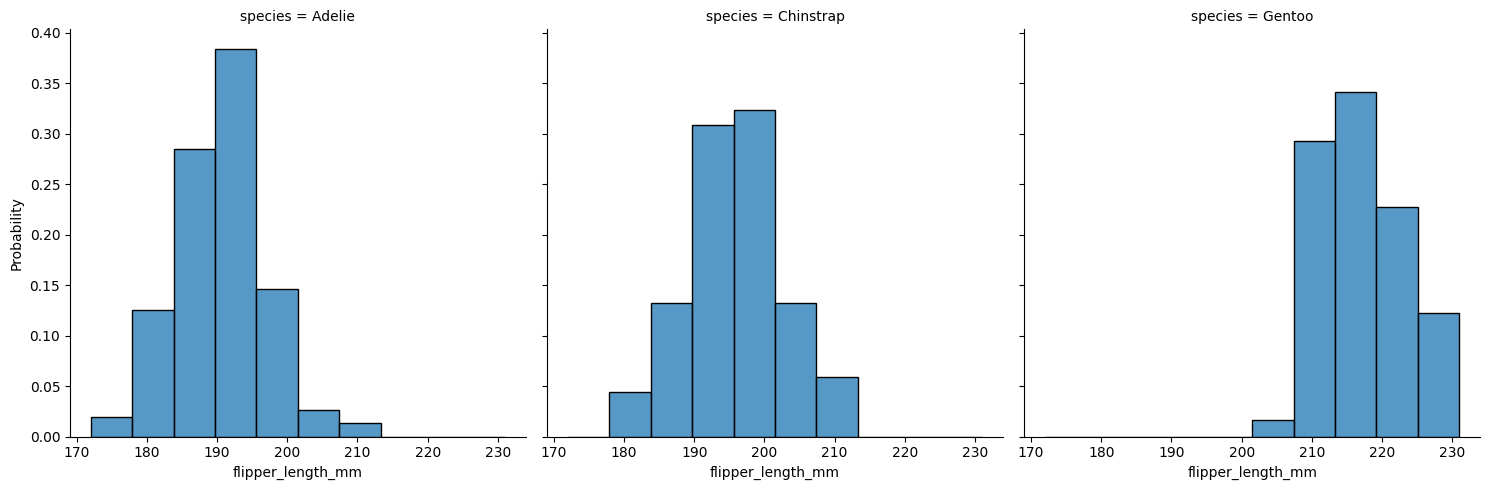

In [13]:
sns.displot(
    penguins, x="flipper_length_mm", col="species",
    stat="probability", # bar heights sum up to 1
    common_norm=False
)

## Empirical cumulative distributions

A third option for visualizing distributions computes the “empirical cumulative distribution function” (ECDF). This plot draws a monotonically-increasing curve through each datapoint such that **the height of the curve reflects the proportion of observations with a smaller value**:

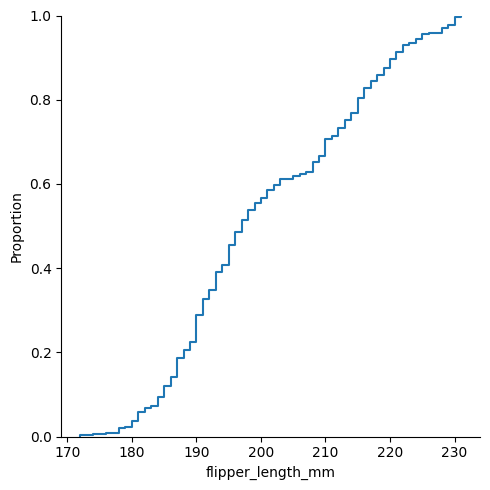

In [14]:
sns.displot(penguins, x="flipper_length_mm", kind="ecdf")

We can see that the median (50th percentile) is around 198. Let's calculate it to verify:

In [17]:
penguins['flipper_length_mm'].median()

np.float64(197.0)

.. and the 99th percentile is around 228. Let's verify:

In [18]:
penguins['flipper_length_mm'].quantile(0.99)

np.float64(230.0)

The ECDF plot has two key advantages.

- Firstly, unlike the histogram or KDE, it directly represents each datapoint. That means there is no bin size or smoothing parameter to consider.
- Secondly, because the curve is monotonically increasing, it is well-suited for comparing multiple distributions:

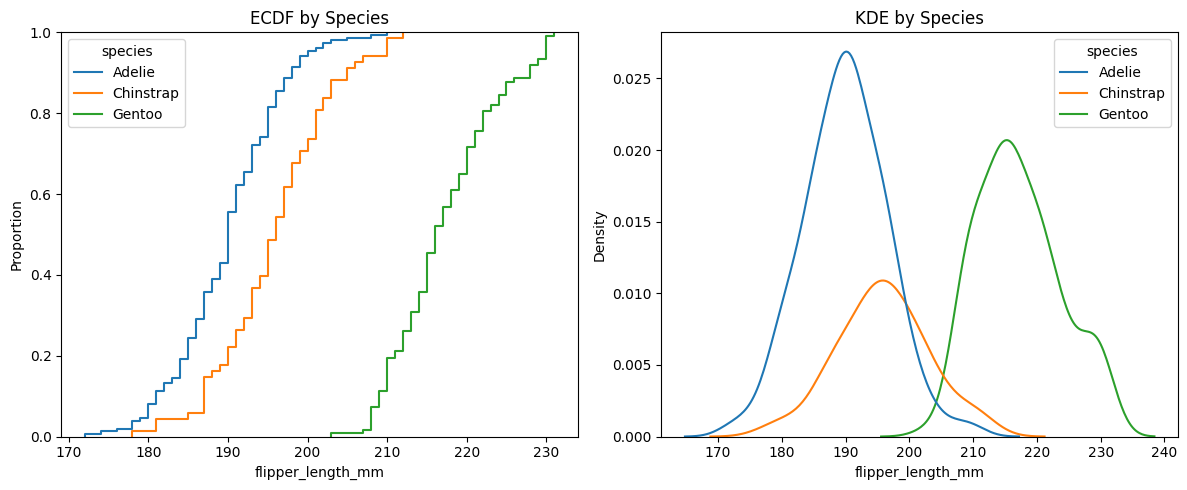

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.ecdfplot(data=penguins, x="flipper_length_mm", hue="species", ax=axes[0])
axes[0].set_title("ECDF by Species")

sns.kdeplot(data=penguins, x="flipper_length_mm", hue="species", ax=axes[1])
axes[1].set_title("KDE by Species")

plt.tight_layout()
plt.show()

The major downside to the ECDF plot is that it represents the shape of the distribution less intuitively than a histogram or density curve. Consider how the bimodality of flipper lengths is immediately apparent in the histogram, but to see it in the ECDF plot, you must look for varying slopes. **Nevertheless, with practice, you can learn to answer all of the important questions about a distribution by examining the ECDF, and doing so can be a powerful approach**.

---

References:

- https://seaborn.pydata.org/tutorial/distributions.html